In [58]:
from google.colab import files

uploaded = files.upload()

Saving Dataset-SA.csv to Dataset-SA (1).csv


In [59]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [60]:
df = pd.read_csv("Dataset-SA.csv")

## **Inspect the Dataset**

In [61]:
#first five rows
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [62]:
#Check the dataset size
df.shape

(205052, 6)

In [63]:
#checking the columns
df.columns

Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')

In [64]:
#Check the sentiment classes


df['Sentiment'].value_counts()

,count
Sentiment,
positive,166581
negative,28232
neutral,10239


In [65]:
#Check missing values
df.isnull().sum()


,0
product_name,0
product_price,0
Rate,0
Review,24664
Summary,11
Sentiment,0


In [66]:
#Check the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


In [67]:
#checking some of the reviews
df[['Review', 'Sentiment']].head(10)

,Review,Sentiment
0,super!,positive
1,awesome,positive
2,fair,positive
3,useless product,negative
4,fair,neutral
5,awesome,positive
6,highly recommended,positive
7,nice,positive
8,unsatisfactory,negative
9,worth the money,positive


### **Data Inspection – Insight**
* The dataset contains 205,052 records and 6 attributes.
* The important NLP columns are Review (text input) and Sentiment (target).
* The dataset has 3 sentiment classes: Positive, Negative, and Neutral.
* Positive reviews dominate the dataset with 166,581 records, while Negative has 28,232 and Neutral has 10,239.
* Review has 24,664 missing values, while Summary has only 11 missing values.
* Other columns (product_name, product_price, Rate, Sentiment) have no missing values.
* Therefore, the dataset is imbalanced, and missing review texts will need to be handled before NLP processing.

In [68]:
# Check rows where the Review text is missing
df[df['Review'].isnull()][['Review', 'Summary', 'Sentiment']].head(10)

,Review,Summary,Sentiment
41625,NaN,best product,positive
41626,NaN,very good,positive
41627,NaN,very comfortablegood qualitylove it,positive
41628,NaN,very soft and comfortable go for it,positive
41629,NaN,super product quality is vry good tnx flipkart,positive
41630,NaN,fits her perfectly and good quality for winter...,positive
41631,NaN,same product,positive
41632,NaN,soft febric,positive
41633,NaN,great innershine and warmth,positive
41634,NaN,superb product,positive


## **Handling the missing values**

In [69]:
# Fill missing Review values using the Summary
df['Review'] = df['Review'].fillna(df['Summary'])

In [70]:
# Check remaining missing values in Review
df['Review'].isnull().sum()

np.int64(2)

In [71]:
# Check the remaining missing Review values
df[df['Review'].isnull()][['Review', 'Summary', 'Sentiment']]

,Review,Summary,Sentiment
47616,NaN,NaN,positive
50559,NaN,NaN,neutral


In [72]:
# Remove rows with no review text
df = df.dropna(subset=['Review'])

In [73]:
# Check remaining missing Review values
df['Review'].isnull().sum()

np.int64(0)

## **Check duplicate reviews**

In [74]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(34375)

In [75]:
# Remove duplicate rows-duplicate records can affect the model's learning and evaluation.
df = df.drop_duplicates()

In [76]:
# Check the dataset size after removing duplicates
df.shape

(170675, 6)

We started with 205,052 rows and now have 170,675 unique records after handling missing reviews and duplicates.

So the dataset is now cleaner and ready for the next inspection stage.

## **Check sentiment distribution again**

In [77]:
# Check sentiment distribution after cleaning
df['Sentiment'].value_counts()

,count
Sentiment,
positive,134700
negative,26473
neutral,9502


In [78]:
# Check the length of each review
df['Review'].str.len().describe()

,Review
count,170675.000000
mean,14.140173
std,12.042634
min,2.000000
25%,9.000000
50%,12.000000
75%,17.000000
max,469.000000


In [79]:
# Display some sample reviews with their sentiment
df[['Review', 'Sentiment']].sample(10, random_state=42)

,Review,Sentiment
59427,very very beautiful n clr is amazine as i expe...,positive
190313,not specified,positive
137488,good choice,positive
126311,fair,neutral
172557,worth every penny,positive
60859,thank you flipkart,positive
147620,value-for-money,positive
10671,must buy!,positive
82713,great product,positive
18317,does the job,positive


## **Text Preprocessing**

### **cleaning the Review text**

In [80]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Clean_Review'] = df['Review'].apply(clean_text)

df[['Review', 'Clean_Review', 'Sentiment']].head(10)

,Review,Clean_Review,Sentiment
0,super!,super,positive
1,awesome,awesome,positive
2,fair,fair,positive
3,useless product,useless product,negative
4,fair,fair,neutral
5,awesome,awesome,positive
6,highly recommended,highly recommended,positive
7,nice,nice,positive
8,unsatisfactory,unsatisfactory,negative
9,worth the money,worth the money,positive


###  **Stopword Removal**

Stopwords are common words such as "the", "is", "and", and "to" that generally
carry limited information for sentiment classification. Removing these words
helps reduce unnecessary text and allows the model to focus on more meaningful
words.

In [81]:
# Download the English stopword list
nltk.download('stopwords')

# Create a set of English stopwords for faster lookup
stop_words = set(stopwords.words('english'))

# Remove stopwords from the cleaned reviews
df['Clean_Review'] = df['Clean_Review'].apply(
    lambda text: ' '.join(
        word for word in text.split()
        if word not in stop_words
    )
)

# Display the original review, processed review, and sentiment
df[['Review', 'Clean_Review', 'Sentiment']].head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Review,Clean_Review,Sentiment
0,super!,super,positive
1,awesome,awesome,positive
2,fair,fair,positive
3,useless product,useless product,negative
4,fair,fair,neutral
5,awesome,awesome,positive
6,highly recommended,highly recommended,positive
7,nice,nice,positive
8,unsatisfactory,unsatisfactory,negative
9,worth the money,worth money,positive


### **Stemming**

Stemming reduces words to their root form by removing common word endings.
This helps group similar words and reduce the number of unique terms.

In [82]:
# Initialize the Porter Stemmer
stemmer = PorterStemmer()

# Apply stemming to each word in the processed review
df['Stemmed_Review'] = df['Clean_Review'].apply(
    lambda text: ' '.join(stemmer.stem(word) for word in text.split())
)

# Display the original, cleaned, and stemmed reviews
df[['Review', 'Clean_Review', 'Stemmed_Review', 'Sentiment']].head(10)

,Review,Clean_Review,Stemmed_Review,Sentiment
0,super!,super,super,positive
1,awesome,awesome,awesom,positive
2,fair,fair,fair,positive
3,useless product,useless product,useless product,negative
4,fair,fair,fair,neutral
5,awesome,awesome,awesom,positive
6,highly recommended,highly recommended,highli recommend,positive
7,nice,nice,nice,positive
8,unsatisfactory,unsatisfactory,unsatisfactori,negative
9,worth the money,worth money,worth money,positive


## **Feature Extraction – TF-IDF**

TF-IDF converts text into numerical features based on word importance.

In [83]:
# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer()

# Convert stemmed reviews into numerical features
X = tfidf.fit_transform(df['Stemmed_Review'])

# Store the sentiment labels
y = df['Sentiment']

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (170675, 4336)


## **Train-Test Split**

The dataset is divided into training and testing sets to evaluate the model on unseen data.

In [84]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (136540, 4336)
Testing data: (34135, 4336)


## **Classification Model – Logistic Regression**

Logistic Regression is used to classify reviews into positive, negative, and neutral sentiments.

In [85]:
# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## **Prediction**

The trained model is used to predict the sentiments of the test reviews.

In [86]:
# Predict sentiments for the test data
y_pred = model.predict(X_test)

# Display the first 10 predictions
print(y_pred[:10])

['positive' 'positive' 'negative' 'negative' 'positive' 'positive'
 'positive' 'positive' 'negative' 'positive']


## **Model Evaluation**

Now in the next step the model is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

In [87]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.8961
Precision: 0.8881
Recall   : 0.8961
F1-Score : 0.8728

Confusion Matrix:
[[ 3927     8  1360]
 [  348   102  1450]
 [  360    22 26558]]


## **Confusion Matrix Visualization**

The confusion matrix is visualized to clearly compare the actual and predicted sentiment classes. It helps identify which sentiments are classified correctly and where the model makes errors.

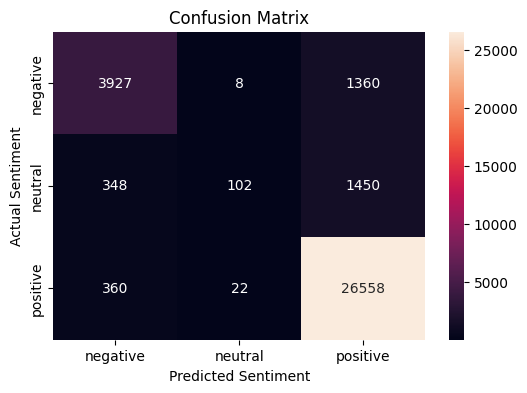

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the sentiment class labels
labels = ['negative', 'neutral', 'positive']

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix')
plt.show()

### **Sample Sentiment Prediction**

Now the trained model is tested on a few new product reviews.

In [89]:
# Sample reviews for testing
sample_reviews = [
    "This product is excellent and worth the money",
    "Very bad product, completely disappointed",
    "It is okay, nothing special"
]

# Apply the same preprocessing used during training
clean_samples = [
    ' '.join(stemmer.stem(word) for word in clean_text(review).split()
             if word not in stop_words)
    for review in sample_reviews
]

# Convert the samples into TF-IDF features
sample_features = tfidf.transform(clean_samples)

# Predict the sentiment
sample_predictions = model.predict(sample_features)

# Display the predictions
for review, sentiment in zip(sample_reviews, sample_predictions):
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}\n")

Review: This product is excellent and worth the money
Predicted Sentiment: positive

Review: Very bad product, completely disappointed
Predicted Sentiment: negative

Review: It is okay, nothing special
Predicted Sentiment: positive



## **Sample Prediction Analysis**

The model correctly classified the clearly positive and negative sample
reviews. However, the neutral review, "It is okay, nothing special", was
classified as positive.

This shows that the model has difficulty distinguishing neutral reviews
from positive reviews. This is a limitation of the current sentiment
classification model and may be influenced by the similarity between
neutral and positive language.

## **Working NLP Application Interface**

A simple user interface is created to allow users to enter a Flipkart product review and receive a predicted sentiment. The trained TF-IDF and Logistic Regression model is used to classify the review as Positive, Negative, or Neutral.

In [90]:
# Install Gradio for the user interface
!pip install -q gradio

In [91]:
# Create the sentiment prediction function and interface

import gradio as gr

def predict_sentiment(review):
    # Clean the user's review
    cleaned_review = clean_text(review)

    # Convert the review into TF-IDF features
    review_tfidf = tfidf.transform([cleaned_review])

    # Predict sentiment
    prediction = model.predict(review_tfidf)[0]

    return prediction.upper()


interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter a Flipkart product review here..."
    ),
    outputs=gr.Textbox(label="Predicted Sentiment"),
    title="Flipkart Review Sentiment Analyzer",
    description="Enter a product review to predict whether it is Positive, Negative, or Neutral."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://da5dbf74456e8e4a34.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
